# 06 · Training a PPO agent & evaluating it against the textbook baseline

The simulator ships a complete **reinforcement-learning stack** (`src/rl/`) implementing
the variable-K shared-weight per-product policy from ADR 0021: a `SetActor` MLP applied
row-wise to a `(K_max, F)` observation tensor, with K sampled per episode from `[1, 20]`
and padded to `K_max = 32`. This notebook drives that stack end-to-end:

1. **Train** a PPO agent with the `src.rl.train` CLI (a tiny, CPU-only smoke run).
2. **Read the training curves** straight from the TensorBoard event file.
3. **Show the new concepts**: variable K across resets, the `(K_max, F)` observation with
   its mask column, the Arbiter config switch, the self-describing checkpoint bundle,
   and a CRN-paired eval against `OrderUpToPolicy` on the reduced CRN tuple.

### What the env actually learns

Each episode the env (`src/rl/env.py`) builds a degenerate three-tier graph —
one `FactoryNode` per active SKU → one trainable `IntermediateNode("S")` → one
`DemandSinkNode` per SKU — and randomises the slice it trains on:

- **variable K** SKUs drawn from a larger catalog (`K_min ≤ K ≤ K_max_episode`),
- a per-episode **store capacity** and **opening cash**, sampled *log-uniform across two
  orders of magnitude* so one policy generalises from corner-shop to flagship,
- **no slot-shuffle** — permutation invariance is structural via the shared-weight actor.

The observation space is `Box(K_MAX * F,)` — the `(K_MAX, F)` set-encoder tensor flattened
to 1-D for gym compatibility. The action space is `Box(K_MAX * 3,)` — the `(K_MAX, 3)`
action tensor flattened. A deterministic **Arbiter** reconciles the joint proposal
against node capacity and the cash budget before orders reach the engine.

> **Tiny-demo caveat.** Everything below runs in a couple of minutes on CPU with no GPU
> and no API key. The training budget here is a few thousand env steps — roughly 1/300th
> of a real run. So expect the trained agent here to *lose* to the baseline: this notebook
> demonstrates the **mechanism**, not a competitive result. And be aware that even at
> ~1,000,000 steps (`--total-env-steps 1000000 --n-envs 8`) the agent still loses to
> `OrderUpToPolicy` across the domain-randomisation range under the parity-correct eval
> harness — notebook 06a analyses such a run honestly. For real training, see
> `src/rl/README.md`.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths resolve
# no matter where the kernel started.
while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 90
print('cwd:', Path.cwd())

cwd: /workspace/.claude/worktrees/issue-05-notebook-06-update


## 1 · The training config (kept deliberately tiny)

`RLConfig` (`src/rl/configs/default.py`) is the single frozen dataclass every part of the
stack reads. Key new knobs vs the fixed-K stack: `--k-min` / `--k-max-episode` replace
the old `--k-active`; `--arbiter-mode` selects proportional or greedy reconciliation;
`--cash-budget-fraction` sets the fraction of cash the Arbiter enforces. We override
the defaults with much smaller values so the whole notebook finishes in under two minutes.

In [2]:
DEMO = dict(
    total_env_steps=4000,   # real run: ~1_000_000
    n_envs=2,               # real run: 8
    episode_length=30,      # real run: 180
    k_min=1,                # sample K from [1, k_max_episode] per episode
    k_max_episode=5,        # real run: 20
    k_catalog=12,           # real run: 100
    arbiter_mode='proportional',  # or 'greedy'
    cash_budget_fraction=1.0,
    n_steps=64,             # rollout length per env per update
    n_epochs=4,
    n_minibatches=2,
    eval_cadence=1000,      # CRN eval (+ checkpoint) every N env steps
    n_eval_seeds=6,         # real run: 32
)

EXPERIMENT = 'nb06_demo'
RUN_ROOT = 'data/notebook_demos/06/runs'   # gitignored; namespaced for this notebook
run_dir = Path(RUN_ROOT) / EXPERIMENT

# Start from a clean slate so re-running the notebook is idempotent.
import shutil
if run_dir.exists():
    shutil.rmtree(run_dir)

# Show the new observation/action shapes
from src.rl.set_encoder import K_MAX, F, OBS_LAYOUT_VERSION, set_obs_shape, set_action_shape
print(f'K_MAX = {K_MAX}  (maximum products per episode, including padding)')
print(f'F     = {F}      (features per product row)')
print(f'(K_max, F) set-obs shape:    {set_obs_shape()}   flattened to {K_MAX * F} for gym')
print(f'(K_max, 3) set-act shape:    {set_action_shape()} flattened to {K_MAX * 3} for gym')
print(f'layout_version: {OBS_LAYOUT_VERSION}')

K_MAX = 32  (maximum products per episode, including padding)
F     = 16      (features per product row)
(K_max, F) set-obs shape:    (32, 16)   flattened to 512 for gym
(K_max, 3) set-act shape:    (32, 3) flattened to 96 for gym
layout_version: 1


## 2 · Train a tiny agent

`src.rl.train` is an `argparse` driver. We invoke it as a subprocess with our tiny flags.
With no `--setup-dir`, the stack uses a **synthetic catalog** — no LLM, no `OPENAI_API_KEY`.

The key new flags: `--k-min` / `--k-max-episode` instead of `--k-active`;
`--arbiter-mode` to switch between proportional and greedy reconciliation.

In [3]:
import subprocess, time

cmd = [
    'uv', 'run', 'python', '-m', 'src.rl.train',
    '--total-env-steps', str(DEMO['total_env_steps']),
    '--n-envs', str(DEMO['n_envs']),
    '--episode-length', str(DEMO['episode_length']),
    '--k-min', str(DEMO['k_min']),
    '--k-max-episode', str(DEMO['k_max_episode']),
    '--k-catalog', str(DEMO['k_catalog']),
    '--arbiter-mode', DEMO['arbiter_mode'],
    '--cash-budget-fraction', str(DEMO['cash_budget_fraction']),
    '--n-steps', str(DEMO['n_steps']),
    '--n-epochs', str(DEMO['n_epochs']),
    '--n-minibatches', str(DEMO['n_minibatches']),
    '--eval-cadence-env-steps', str(DEMO['eval_cadence']),
    '--n-eval-seeds', str(DEMO['n_eval_seeds']),
    '--experiment-name', EXPERIMENT,
    '--tb-log-dir', RUN_ROOT,
    '--checkpoint-dir', RUN_ROOT,
]
print('running:\n ', ' '.join(cmd), '\n')

t0 = time.time()
proc = subprocess.run(cmd, capture_output=True, text=True)
wall = time.time() - t0

print(f'return code: {proc.returncode}   wall time: {wall:.1f}s\n')
tail = [ln for ln in proc.stderr.splitlines() if ln.strip()][-12:]
print('\n'.join(tail))
assert proc.returncode == 0, 'training subprocess failed'

running:
  uv run python -m src.rl.train --total-env-steps 4000 --n-envs 2 --episode-length 30 --k-min 1 --k-max-episode 5 --k-catalog 12 --arbiter-mode proportional --cash-budget-fraction 1.0 --n-steps 64 --n-epochs 4 --n-minibatches 2 --eval-cadence-env-steps 1000 --n-eval-seeds 6 --experiment-name nb06_demo --tb-log-dir data/notebook_demos/06/runs --checkpoint-dir data/notebook_demos/06/runs 



return code: 0   wall time: 18.9s

         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 679ms
[train] device=cpu
[train] Synthetic catalog: 12 products.
[train] SyncVectorEnv: 2 envs, obs_dim=512, act_dim=96
[train] TensorBoard log dir: data/notebook_demos/06/runs/nb06_demo
[train] Eval enabled: 6 seeds, cadence=1000 env steps.
[train] Starting PPO: total_env_steps=4000, K_min=1, K_max_episode=5, seed=0
[train] Final checkpoint saved: data/notebook_demos/06/runs/nb06_demo/checkpoints/actor_step0000004000.pt
[train] Done.


## 3 · Variable K across resets

With `--k-min 1 --k-max-episode 5`, each episode samples K independently. The gym
observation is a flat `(K_MAX * F,)` vector; we reshape it to `(K_MAX, F)` and read
the mask column (`ROW_MASK = F-1 = 15`): active rows have `mask = 1`, padded rows
are all-zero.

In [4]:
import numpy as np
from src.rl.env import RLEnv
from src.rl.configs.default import RLConfig
from src.rl.episode_sampler import make_synthetic_catalog
from src.rl.set_encoder import ROW_MASK, K_MAX, F

cfg = RLConfig(
    K_min=DEMO['k_min'],
    K_max_episode=DEMO['k_max_episode'],
    K_catalog=DEMO['k_catalog'],
    episode_length=DEMO['episode_length'],
    arbiter_mode=DEMO['arbiter_mode'],
    cash_budget_fraction=DEMO['cash_budget_fraction'],
)

catalog = make_synthetic_catalog(cfg.K_catalog)
env = RLEnv(catalog=catalog, config=cfg)

for trial in range(2):
    obs_flat, info = env.reset(seed=trial)
    # Gym obs is flat (K_MAX*F,); reshape to (K_MAX, F) for inspection
    obs_2d = obs_flat.reshape(K_MAX, F)
    mask_col = obs_2d[:, ROW_MASK]
    k_active = int(mask_col.sum())
    print(f'Reset {trial}: K_active = {k_active}, gym obs shape = {obs_flat.shape}')
    print(f'  obs_2d shape  (K_MAX, F): {obs_2d.shape}')
    print(f'  Active rows   (mask=1): rows 0..{k_active-1}')
    print(f'  Padded rows   (mask=0): rows {k_active}..{K_MAX-1}')
    print(f'  mask column (first {k_active+2}): {mask_col[:k_active+2].round(0).astype(int).tolist()}')
    print()

Reset 0: K_active = 4, gym obs shape = (512,)
  obs_2d shape  (K_MAX, F): (32, 16)
  Active rows   (mask=1): rows 0..3
  Padded rows   (mask=0): rows 4..31
  mask column (first 6): [1, 1, 1, 1, 0, 0]

Reset 1: K_active = 5, gym obs shape = (512,)
  obs_2d shape  (K_MAX, F): (32, 16)
  Active rows   (mask=1): rows 0..4
  Padded rows   (mask=0): rows 5..31
  mask column (first 7): [1, 1, 1, 1, 1, 0, 0]



## 4 · What landed on disk — self-describing checkpoints

The run wrote a TensorBoard event file plus one checkpoint per eval call and a final one
at `total_env_steps`. Checkpoints are **self-describing bundles** containing the actor
`state_dict`, the training config, and the observation layout version — a stale checkpoint
fails loudly on load instead of with a shape error or silently.

In [5]:
from src.rl.checkpoint import load as ckpt_load

event_files = sorted(run_dir.glob('events.out.tfevents.*'))
ckpts = sorted((run_dir / 'checkpoints').glob('actor_step*.pt'))

print('event files:', [p.name for p in event_files])
print('checkpoints:')
for p in ckpts:
    print(f'  {p.name}  ({p.stat().st_size/1024:.0f} KB)')
assert event_files and ckpts, 'need at least one event file and one checkpoint'

# Inspect the bundle structure
bundle = ckpt_load(ckpts[-1])
print(f'\ncheckpoint bundle keys: {list(bundle.keys())}')
print(f'  layout_version: {bundle["layout_version"]}')
print(f'  config keys:    {list(bundle["config"].keys())[:8]} ...')
print(f'  state_dict keys (first 5): {list(bundle["state_dict"].keys())[:5]}')

event files: ['events.out.tfevents.1781181093.b883a6a55894.3823.0']
checkpoints:
  actor_step0000001024.pt  (25 KB)
  actor_step0000002048.pt  (25 KB)
  actor_step0000003072.pt  (25 KB)
  actor_step0000004000.pt  (25 KB)

checkpoint bundle keys: ['state_dict', 'config', 'layout_version']
  layout_version: 1
  config keys:    ['K_min', 'K_max_episode', 'K_catalog', 'arbiter_mode', 'cash_budget_fraction', 'episode_length', 'lr', 'n_steps'] ...
  state_dict keys (first 5): ['log_std', 'net.0.weight', 'net.0.bias', 'net.2.weight', 'net.2.bias']


## 5 · Arbiter config switch

The Arbiter projects the joint order proposal onto the feasible set defined by capacity
and the cash budget. Both `proportional` and `greedy` variants use the same checkpoint
format — the mode is a runtime config switch, not an architecture change. The `SetActor`
handles any K from 1 to `K_max = 32` with the same weights.

In [6]:
import torch
from src.rl.agents.set_actor_critic import SetActor

bundle = ckpt_load(ckpts[-1])
actor = SetActor()
actor.load_state_dict(bundle['state_dict'])
actor.eval()

print('Loaded SetActor from checkpoint.')
print(f'  layout_version: {bundle["layout_version"]}  (validated on load)')
print(f'  arbiter_mode in saved config: {bundle["config"].get("arbiter_mode", "proportional")}')
print()
print('To switch at eval time: --arbiter-mode greedy (same state_dict, different reconciliation)')
print()
# Verify the same weights work for K=1, K=5, K=20
for k in [1, 5, 20]:
    # Build a fake flat obs with k active rows
    obs_fake = np.zeros(K_MAX * F, dtype=np.float32)
    obs_2d = obs_fake.reshape(K_MAX, F)
    obs_2d[:k, ROW_MASK] = 1.0  # activate first k rows
    obs_t  = torch.tensor(obs_2d, dtype=torch.float32).unsqueeze(0)   # (1, K_MAX, F)
    mask_t = torch.tensor(obs_2d[:, ROW_MASK], dtype=torch.float32).unsqueeze(0)  # (1, K_MAX)
    with torch.no_grad():
        action, logp, _ = actor.get_action_and_log_prob(obs_t, mask_t)
    print(f'  K={k:2d}: action shape {tuple(action.shape)}, log_prob {logp.item():.3f}')

Loaded SetActor from checkpoint.
  layout_version: 1  (validated on load)
  arbiter_mode in saved config: proportional

To switch at eval time: --arbiter-mode greedy (same state_dict, different reconciliation)



  K= 1: action shape (1, 32, 3), log_prob -2.168
  K= 5: action shape (1, 32, 3), log_prob -9.203
  K=20: action shape (1, 32, 3), log_prob -40.853


## 6 · Read the training curves

The event file holds the same scalars TensorBoard would show. We print the available
tags first (never hard-code them), then plot whichever exist.

In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(event_files[0]))
ea.Reload()
scalar_tags = ea.Tags()['scalars']
print(f'{len(scalar_tags)} scalar tags logged:\n')
for t in scalar_tags:
    print(' ', t)

def scalar_series(tag):
    'Return (steps, values) for a scalar tag, or ([], []) if absent.'
    if tag not in scalar_tags:
        return [], []
    evs = ea.Scalars(tag)
    return [e.step for e in evs], [e.value for e in evs]

21 scalar tags logged:

  train/episodic_return
  train/episodic_length
  losses/value_loss
  losses/policy_loss
  losses/entropy
  losses/approx_kl
  losses/clipfrac
  charts/learning_rate
  charts/SPS
  eval/rl_return
  eval/baseline_return
  eval/paired_uplift
  eval/win_rate
  eval/rl_stockout_rate
  eval/rl_inventory_turnover
  eval/rl_mean_price_pct_of_msrp
  eval/rl_net_profit
  eval/baseline_stockout_rate
  eval/baseline_inventory_turnover
  eval/baseline_mean_price_pct_of_msrp
  eval/baseline_net_profit


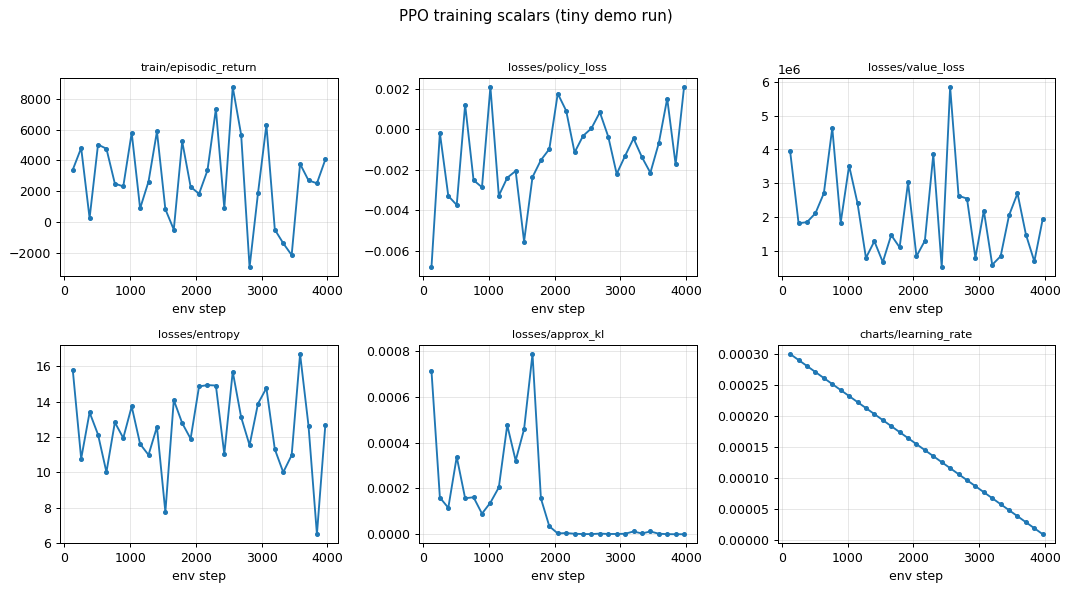

In [8]:
panel_tags = [
    'train/episodic_return', 'losses/policy_loss', 'losses/value_loss',
    'losses/entropy', 'losses/approx_kl', 'charts/learning_rate',
]
present = [t for t in panel_tags if t in scalar_tags]
ncol = 3
nrow = (len(present) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.2 * nrow))
axes = axes.ravel()
for ax, tag in zip(axes, present):
    steps, vals = scalar_series(tag)
    ax.plot(steps, vals, marker='o', ms=3)
    ax.set_title(tag, fontsize=9)
    ax.set_xlabel('env step')
    ax.grid(alpha=0.3)
for ax in axes[len(present):]:
    ax.axis('off')
fig.suptitle('PPO training scalars (tiny demo run)', y=1.02)
plt.tight_layout()
plt.show()

### The CRN eval scalars logged *during* training

The eval callback also writes `eval/*` scalars at every cadence point. `eval/paired_uplift`
is the headline number: the mean per-seed `(RL − baseline)` net profit on identical worlds.

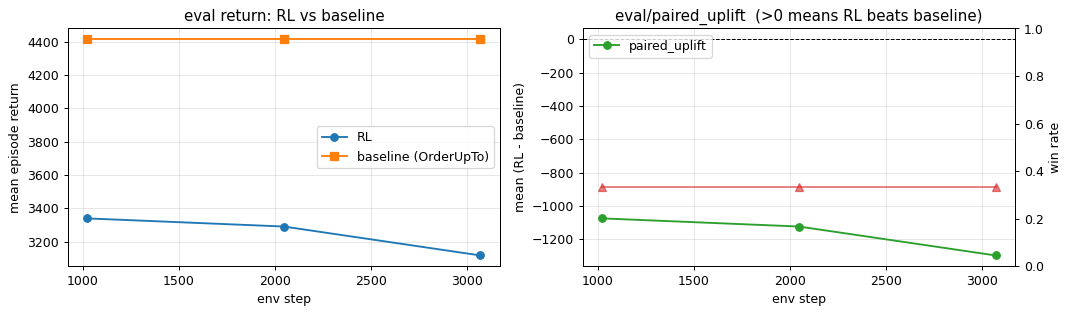

final logged paired_uplift: -1296.1   (negative is expected at this tiny budget)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

s_rl, v_rl = scalar_series('eval/rl_return')
s_bl, v_bl = scalar_series('eval/baseline_return')
if v_rl:
    axes[0].plot(s_rl, v_rl, marker='o', label='RL')
if v_bl:
    axes[0].plot(s_bl, v_bl, marker='s', label='baseline (OrderUpTo)')
axes[0].set_title('eval return: RL vs baseline')
axes[0].set_xlabel('env step'); axes[0].set_ylabel('mean episode return')
axes[0].legend(); axes[0].grid(alpha=0.3)

s_up, v_up = scalar_series('eval/paired_uplift')
s_wr, v_wr = scalar_series('eval/win_rate')
ax2 = axes[1]
if v_up:
    ax2.plot(s_up, v_up, marker='o', color='C2', label='paired_uplift')
    ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set_title('eval/paired_uplift  (>0 means RL beats baseline)')
ax2.set_xlabel('env step'); ax2.set_ylabel('mean (RL - baseline)')
ax2.grid(alpha=0.3)
if v_wr:
    ax2b = ax2.twinx()
    ax2b.plot(s_wr, v_wr, marker='^', color='C3', alpha=0.6, label='win_rate')
    ax2b.set_ylabel('win rate'); ax2b.set_ylim(0, 1)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

if v_up:
    print(f'final logged paired_uplift: {v_up[-1]:+.1f}   '
          f'(negative is expected at this tiny budget)')

## 7 · CRN-paired eval against `OrderUpToPolicy` (offline)

The CRN guarantee: for each seed, the RL and baseline arms share
`(world_seed, capacity, balance, active_subset, allocation_sub_seed)`. `slot_permutation`
is absent — permutation invariance is structural. Any gap is the policy.

Both arms run through the identical `Runner.run()` engine code path (ADR 0022). The RL
policy callable is wrapped in `RLNodePolicy` internally by `evaluate()`, which means the
Arbiter is applied at eval exactly as in training — train/eval dynamics are identical through
one shared code path. The `rl_policy_fn` receives a flat `(K_MAX * F,)` obs vector (the gym
format) and returns a flat `(K_MAX * 3,)` action vector; `evaluate()` handles the wrapping.

In [10]:
from src.rl.eval import build_eval_seeds, evaluate
from src.sim.policy import OrderUpToPolicy

def rl_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    """obs_flat: flat (K_MAX * F,); returns flat (K_MAX * 3,)."""
    obs_2d = torch.tensor(obs_flat, dtype=torch.float32).reshape(1, K_MAX, F)
    mask   = obs_2d[..., ROW_MASK]  # (1, K_MAX)
    with torch.no_grad():
        action, _, _ = actor.get_action_and_log_prob(obs_2d, mask)
    return action.squeeze(0).reshape(K_MAX * 3).numpy()

eval_specs = build_eval_seeds(catalog, cfg, n_seeds=DEMO['n_eval_seeds'])
print(f'built {len(eval_specs)} held-out CRN eval specs')
print(f'CRN tuple: (world_seed, capacity, balance, active_subset, allocation_sub_seed)')
print(f'  slot_permutation absent — permutation invariance is structural')

metrics = evaluate(
    rl_policy_fn=rl_policy_fn,
    baseline_policy_factory=lambda: OrderUpToPolicy(),
    eval_specs=eval_specs,
    config=cfg,
)

rows = []
for kpi in ['return', 'net_profit', 'stockout_rate', 'inventory_turnover', 'mean_price_pct_of_msrp']:
    rl_k, bl_k = f'eval/rl_{kpi}', f'eval/baseline_{kpi}'
    if rl_k in metrics and bl_k in metrics:
        rows.append((kpi, metrics[rl_k], metrics[bl_k]))
kpi_df = pd.DataFrame(rows, columns=['kpi', 'RL', 'baseline'])
kpi_df['RL - baseline'] = kpi_df['RL'] - kpi_df['baseline']
display(kpi_df.set_index('kpi').round(3))

print(f'\npaired_uplift: {metrics["eval/paired_uplift"]:+.1f}')
print(f'win_rate:      {metrics["eval/win_rate"]:.2f}')

built 6 held-out CRN eval specs
CRN tuple: (world_seed, capacity, balance, active_subset, allocation_sub_seed)
  slot_permutation absent — permutation invariance is structural


,RL,baseline,RL - baseline
kpi,,,
return,3319.983,4413.530,-1093.547
net_profit,3319.983,4413.530,-1093.547
stockout_rate,0.003,0.014,-0.011
inventory_turnover,6.201,6.106,0.096
mean_price_pct_of_msrp,1.000,1.000,0.000



paired_uplift: -1093.5
win_rate:      0.33


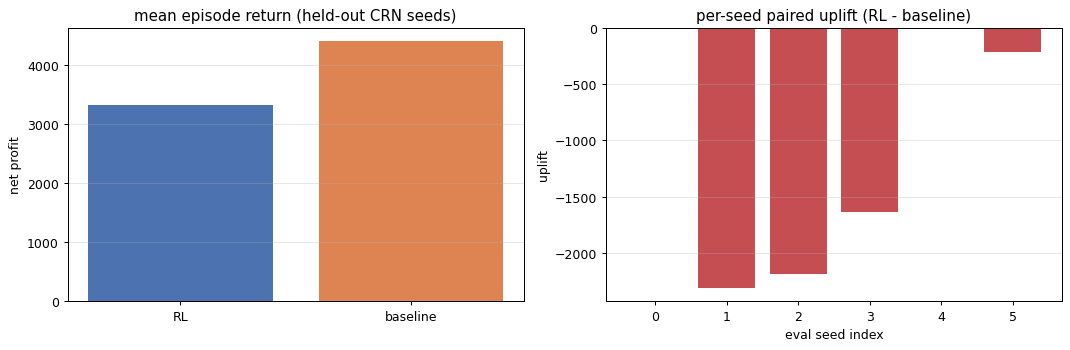

,seed_idx,rl_return,baseline_return,uplift
0,0,677.0,677.0,0.0
1,1,5724.1,8035.0,-2310.9
2,2,2883.0,5069.3,-2186.4
3,3,2841.9,4481.2,-1639.3
4,4,4103.1,4103.1,0.0
5,5,3899.5,4115.6,-216.1


In [11]:
per_seed = []
for i, spec in enumerate(eval_specs):
    m1 = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=cfg)
    per_seed.append((i, m1['eval/rl_return'], m1['eval/baseline_return']))
seed_df = pd.DataFrame(per_seed, columns=['seed_idx', 'rl_return', 'baseline_return'])
seed_df['uplift'] = seed_df['rl_return'] - seed_df['baseline_return']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['RL', 'baseline'],
            [metrics['eval/rl_return'], metrics['eval/baseline_return']],
            color=['#4C72B0', '#DD8452'])
axes[0].set_title('mean episode return (held-out CRN seeds)')
axes[0].set_ylabel('net profit')
axes[0].grid(axis='y', alpha=0.3)

colors = ['#55A868' if u >= 0 else '#C44E52' for u in seed_df['uplift']]
axes[1].bar(seed_df['seed_idx'], seed_df['uplift'], color=colors)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_title('per-seed paired uplift (RL - baseline)')
axes[1].set_xlabel('eval seed index'); axes[1].set_ylabel('uplift')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
display(seed_df.round(1))

### Reading the result honestly

At ~4,000 env steps the agent has barely begun to learn, so the baseline `OrderUpToPolicy`
almost certainly wins. **That is the expected, correct outcome for a tiny demo.** What this
notebook proves is that every link in the chain works:

- the PPO loop trains and logs scalars + self-describing checkpoints,
- each reset samples a fresh K and pads the observation to `(K_max, F)` (flattened to gym),
- the Arbiter reconciles the joint proposal against capacity and cash budget,
- both eval arms run through `Runner.run()` via `RLNodePolicy` — identical engine dynamics
  to training, so any observed gap is attributable to the policy alone,
- the `SetActor` loads via `checkpoint.load()` with layout-version validation,
- the reduced CRN tuple (no `slot_permutation`) produces apples-to-apples evaluation.

Two footnotes on the numbers above. The per-seed uplifts of **exactly 0.0** (seeds 0
and 4) are degenerate over-stocked worlds: the sampled capacity makes the initial
inventory (`capacity // K`) exceed total episode demand, so neither arm ever places an
order and both runs are bit-identical. And `win_rate` counts those ties as wins —
0.33 here is 2 ties and 0 real wins out of 6 seeds.

Scaling the budget up (`--total-env-steps 1000000 --n-envs 8 --k-min 1
--k-max-episode 20 --episode-length 180`) improves the agent substantially, but at 1 M
steps it *still* loses to the baseline across the domain-randomisation range under the
parity-correct eval — see notebook 06a for the full analysis. These are the flags for a
"real" training run, not a recipe for beating `OrderUpToPolicy`.

## Where to next

- `src/rl/README.md` — full reference: observation/action layout, Arbiter, CLI flags,
  checkpoint format, CRN eval contract, and the K-generalisation recipe; includes the
  checkpoint-attach recipe (`RLNodePolicy.from_checkpoint` + `policy_overrides` +
  `Runner.run()`) for deploying a trained policy on any intermediate node in a larger graph.
- `uv run tensorboard --logdir data/notebook_demos/06/runs/` — view these curves live.
- For a "real" training run: `--total-env-steps 1000000 --n-envs 8 --k-min 1
  --k-max-episode 20` (optionally `--arbiter-mode greedy` and `--setup-dir setups/...`).
  Note: even at that budget the agent does not beat `OrderUpToPolicy` under the
  parity-correct eval — see 06a.
- **Notebook 06a** loads a 1 M-step run with multiple eval-cadence checkpoints and
  analyses it in depth: model selection from the learning curve, variable-K inference,
  a deep CRN episode comparison, regime analysis (including a stress test of the
  capacity-starved regime and a proportional-vs-greedy Arbiter comparison), the implicit
  assortment demo, a permutation-equivariance check, and a worked attach-and-run demo
  (`RLNodePolicy` attached via `Runner` on held-out worlds).